# **Netflix Recommendation Engine**

**What are Recommender Systems?**

Recommender systems are algorithms designed to suggest relevant items to users. These systems are used in various domains such as e-commerce, streaming services, and social media. They enhance user experience by filtering vast amounts of information to deliver personalized content.

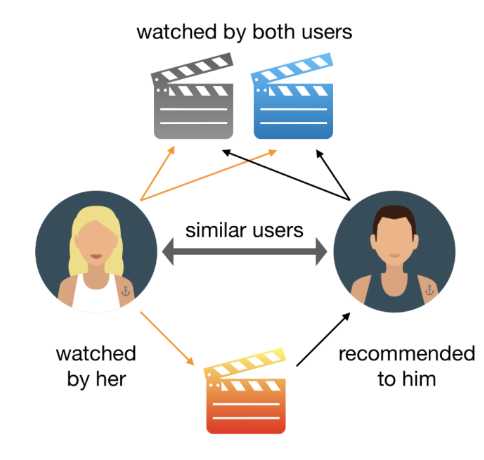

#SVD (Singular Value Decomposition) in a recommendation system works by finding patterns in user preferences and item similarities.

Here's a basic idea without going deep into the topic

**1) What the System Has: A big table (matrix) with users on one side and items (like movies) on the other. Users give ratings to items, but not everyone has rated everything**

**2) What SVD Does: SVD looks at the ratings that are available and tries to figure out the hidden connections between users and items. It learns what kind of movies users like based on their previous ratings**

**3) How It Helps: Once SVD understands these patterns, it can predict how a user might rate a movie they haven’t seen yet. Based on these predictions, the system recommends movies that the user is most likely to enjoy**

**In simple terms:**

**Think of SVD as a way to summarize the information in a matrix by identifying its key components.**

**It reduces a high-dimensional matrix into smaller dimensions while preserving the most important patterns in the data.**

In [ ]:
!pip uninstall -y numpy
#surprise works only with NumPy 1.x                   # Uninstall the current version of Numpy
# Install surprise library now

#scikit-surprise (or simply Surprise) is a Python library used to build Recommendation Systems.
#It is mainly used for collaborative filtering — like Netflix, Amazon, YouTube recommendations.

In [1]:
!pip install numpy==1.26.4                           # Install numpy version 1.26.4
!pip install scikit-surprise --prefer-binary

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 47.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... canceled
ERROR: Operation cancelled by user
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
# Dont import numpy now because we have already installed numpy verision 1.26.4
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading dataset file having 2 crore 40 lakh 58 thousand records

netflix_dataset = pd.read_csv('/content/combined_data_1[1].txt',header = None, names = ['Cust_Id', 'Rating'], usecols = [0,1])
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [4]:
netflix_dataset.tail()

,Cust_Id,Rating
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0
24058262,1704416,3.0


In [5]:
netflix_dataset.dtypes

,0
Cust_Id,object
Rating,float64


In [6]:
netflix_dataset.isnull().sum()

,0
Cust_Id,0
Rating,4499


# Finding the movie count by assumiung that if there is NaN in Rating column so in front of it , there is a movie id

In [7]:
#get the movie count ( as the NaN values in Rating column will show how many movie are there )
movie_count=netflix_dataset.isnull().sum()
movie_count=movie_count["Rating"]
movie_count

np.int64(4499)

# Finding the total unqiue customer id by substracting the movie count from uniuque values in cust id column

In [8]:
#to claculate how many customers we are having in the dataset
customer_count=netflix_dataset['Cust_Id'].nunique()

In [9]:
customer_count

475257

In [10]:
customer_count - movie_count  # Total number of customers that we have after removing movie id from the column

np.int64(470758)

**we have totak 4 lakh , 70 thousand and 7 hundred 58 unique customeras**

In [11]:
#get the total number of ratings given by the customers to all movies combined

rating_count=netflix_dataset['Cust_Id'].count()-movie_count  # In Customer id column we will remove movie id to get how many total rating are there
rating_count

np.int64(24053764)

In [12]:
#To find out how many people have rated the movies as 1, 2, 3,4,5 stars ratings to the movies
stars=netflix_dataset.groupby('Rating')['Rating'].agg(['count'])

In [13]:
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


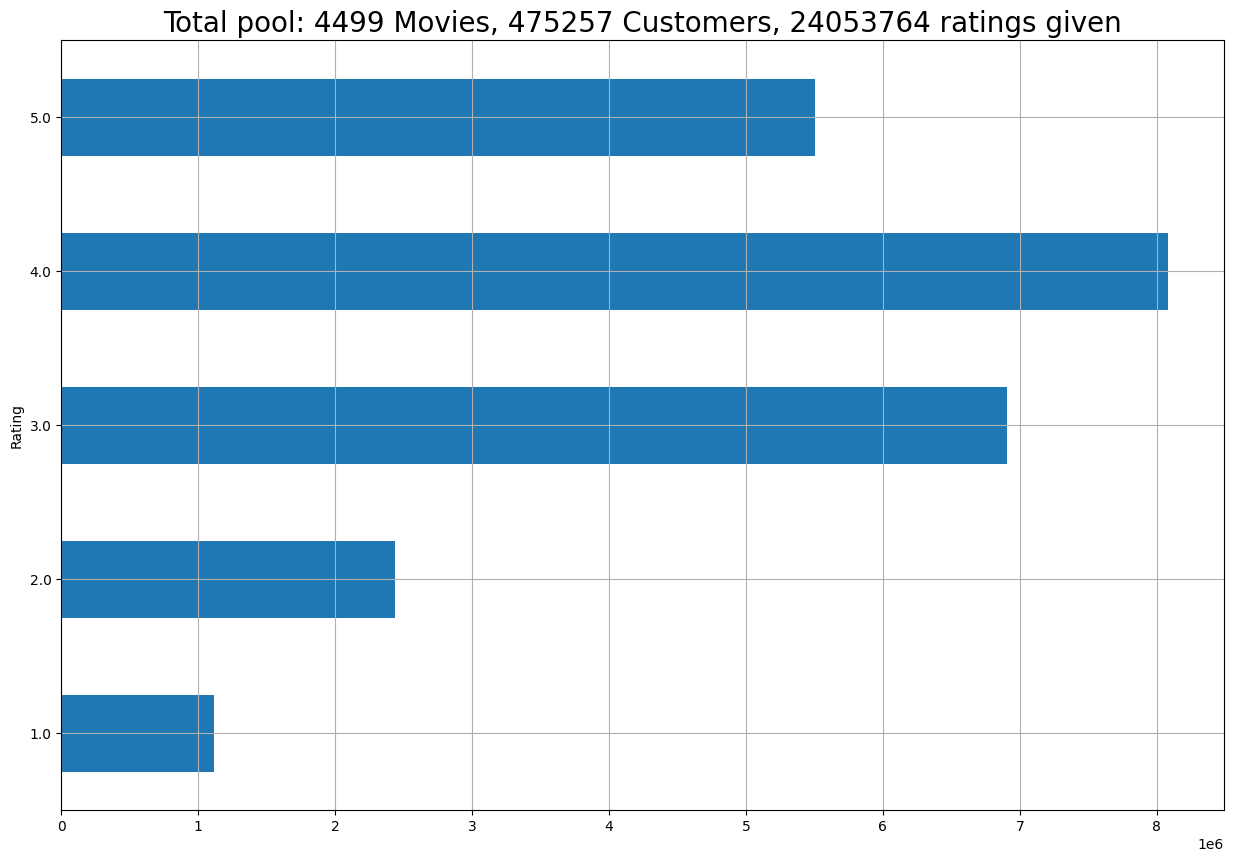

In [14]:
ax=stars.plot(kind='barh', legend=False, figsize=(15,10))

plt.title(f'Total pool: {movie_count} Movies, {customer_count} Customers, {rating_count} ratings given', fontsize=20)
plt.grid(True)

In [15]:
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [16]:
# Lets just make a clear dataframe to find how many MovieId are there
movie_id=None
movie_np =[]
# Iterate over the DataFrame rows
for cust_id in netflix_dataset['Cust_Id']:
    if ':' in cust_id:
      # Update the current movie ID
      movie_id = int(cust_id.replace(':', ''))
    movie_np.append(movie_id)

In [17]:
movie_np  # Movie id columns that we can add in our dataset

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [18]:
# Add the new column to the DataFrame
netflix_dataset['Movie_Id'] = movie_np

In [19]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [20]:
netflix_dataset = netflix_dataset[netflix_dataset['Rating'].notna()]
# to keep only the rows where the 'Rating' column is not null (i.e., it excludes rows where the 'Rating' is NaN)

In [21]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [22]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [23]:
# Now we dont hav movie if in cust id column we have removed all 1:Nan , 2:Nan so lets fix the data type now
netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)

/tmp/ipykernel_1398/280181150.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)


In [24]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [25]:
#pre-filtering
#now we will remove all the users that have rated less movies and
#also all those movies that has been rated less in numbers

In [26]:
dataset_movie_summary=netflix_dataset.groupby('Movie_Id')['Rating'].agg(["count"])

In [27]:
dataset_movie_summary

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [28]:
#now we will create a benchmark
movie_benchmark=round(dataset_movie_summary['count'].quantile(0.6),0)
movie_benchmark

np.float64(908.0)

In [29]:
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index
drop_movie_list  # In this lst all movies are there those are having less rating then bencmarsk so reove them

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [30]:
len(drop_movie_list)

2699

In [31]:
4499-2699  #movies left

1800

In [32]:
#now we will remove all the users that are in-active
dataset_cust_summary=netflix_dataset.groupby('Cust_Id')['Rating'].agg(["count"])
dataset_cust_summary

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [33]:
cust_benchmark=round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark

np.float64(36.0)

In [34]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=282042)

In [35]:
len(drop_cust_list)

282042

# Lets remove all movies that has been rated less than 908 times

# Lets remove all customers that have rated less than 36 movies

In [36]:
netflix_dataset=netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_list)]
print('After the triming, the shape is: {}'.format(netflix_dataset.shape))

After the triming, the shape is: (19695836, 3)


In [37]:
netflix_dataset  # Clean netflix data !!!!!!!!

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [38]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19695836 entries, 696 to 24056846
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 601.1 MB


# **Model Building**

In [50]:
df_title = pd.read_csv("/content/movie_titles _1_.csv",   encoding='latin',header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name' ])

In [51]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [52]:
# Install numpy
!pip install surprise

In [53]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [54]:
reader=Reader()

In [55]:
#we only work with top 100K rows for quick runtime
data=  Dataset.load_from_df(netflix_dataset[['Cust_Id','Movie_Id','Rating']][:100000], reader)

In [56]:
model=SVD()  # Creating a SVD model

In [57]:
cross_validate(model, data, measures=['RMSE'], cv=3)  # Trained the model

{'test_rmse': array([1.01938849, 1.0161016 , 1.02197472]),
 'fit_time': (2.091433048248291, 2.380584239959717, 2.9880006313323975),
 'test_time': (0.7966203689575195, 0.719994068145752, 0.3716566562652588)}

# **Use model for making Recommendation for a specific user**

In [58]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [59]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [61]:
import numpy as np
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

# 1) Use a random sample of USERS (not the first 100,000 rows).
#    Your file is sorted by movie, so [:100000] only covers the first few
#    movies. Sampling users keeps all movies represented.
rng = np.random.default_rng(42)
all_users = netflix_dataset["Cust_Id"].unique()
sample_users = rng.choice(all_users, size=20000, replace=False)
if 1331154 in all_users:                       # keep your demo user
    sample_users = np.union1d(sample_users, [1331154])

sample = netflix_dataset[netflix_dataset["Cust_Id"].isin(sample_users)]
print("Training rows:", sample.shape[0])

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(sample[["Cust_Id", "Movie_Id", "Rating"]], reader)

# 2) Evaluate (optional, for your report)
cross_validate(SVD(n_factors=50, random_state=42), data,
               measures=["RMSE"], cv=3, verbose=True)

# 3) Train the FINAL model on all sampled data
trainset = data.build_full_trainset()
model = SVD(n_factors=50, random_state=42)
model.fit(trainset)

# 4) Export small files for the website
user_ids = np.array([trainset.to_raw_uid(i) for i in range(trainset.n_users)])
item_ids = np.array([trainset.to_raw_iid(i) for i in range(trainset.n_items)])

# which movies each user already rated (so the app can hide them)
indptr, indices = [0], []
for u in range(trainset.n_users):
    indices.extend(i for i, _ in trainset.ur[u])
    indptr.append(len(indices))

np.savez_compressed(
    "model_artifacts.npz",
    pu=model.pu.astype("float32"),
    qi=model.qi.astype("float32"),
    bu=model.bu.astype("float32"),
    bi=model.bi.astype("float32"),
    mu=np.float32(trainset.global_mean),
    user_ids=user_ids.astype("int64"),
    item_ids=item_ids.astype("int64"),
    rated_indptr=np.array(indptr, dtype="int64"),
    rated_indices=np.array(indices, dtype="int32"),
)

movies = df_title[df_title["Movie_Id"].isin(item_ids)].copy()
movies["Year"] = movies["Year"].fillna(0).astype(int)
movies.to_csv("movies.csv", index=False)

# 5) Download both files to your computer
import os
from google.colab import files
print("model_artifacts.npz size (MB):", round(os.path.getsize("model_artifacts.npz")/1e6, 1))
files.download("model_artifacts.npz")
files.download("movies.csv")

Training rows: 2097565
Evaluating RMSE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.8843  0.8845  0.8852  0.8847  0.0004  
Fit time          17.39   18.63   18.03   18.02   0.50    
Test time         8.36    7.05    6.50    7.30    0.78    
model_artifacts.npz size (MB): 6.8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
# Filter the dataset for the specific user you have selected to make recokmnedation to that user
user_ratings = netflix_dataset[netflix_dataset['Cust_Id'] == 1331154]  # niharika
user_ratings

,Cust_Id,Rating,Movie_Id
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [63]:
# Find the number of unique movies rated by the user
movies_rated_by_user = user_ratings['Movie_Id'].nunique()

print(f"User 1331154 has rated {movies_rated_by_user} unique movies.")

User 1331154 has rated 253 unique movies.


In [64]:
copy_data_for_user = df_title.copy()   #making a copy for each individual customer for the recomendation
copy_data_for_user

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [65]:
CLEAN_copy_data_for_user = copy_data_for_user[~copy_data_for_user['Movie_Id'].isin(drop_movie_list)]
CLEAN_copy_data_for_user   # Removing the movie les then benchmark for this user

,Movie_Id,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [66]:
CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)
# predict the score (rating) that a user (with user ID 1331154) might give to a list of movies.
# core thing

/tmp/ipykernel_1398/2454269427.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)


In [67]:
CLEAN_copy_data_for_user

,Movie_Id,Year,Name,Estimate_Score
2,3,1997.0,Character,3.920605
4,5,2004.0,The Rise and Fall of ECW,4.209445
5,6,1997.0,Sick,3.294750
7,8,2004.0,What the #$*! Do We Know!?,3.374077
15,16,1996.0,Screamers,3.054286
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.629262
17766,17767,2004.0,Fidel Castro: American Experience,3.629262
17767,17768,2000.0,Epoch,3.629262
17768,17769,2003.0,The Company,3.629262


In [68]:
CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False) # Descending order estimated score

,Movie_Id,Year,Name,Estimate_Score
3455,3456,2004.0,Lost: Season 1,4.904960
4426,4427,2001.0,The West Wing: Season 3,4.818948
2802,2803,1995.0,Pride and Prejudice,4.740856
2451,2452,2001.0,Lord of the Rings: The Fellowship of the Ring,4.707092
2113,2114,2002.0,Firefly,4.695859
...,...,...,...,...
1292,1293,1996.0,Children of the Corn 4: The Gathering,1.953564
3020,3021,2003.0,House of the Dead,1.884931
4393,4394,2001.0,Druids,1.869698
3504,3505,2001.0,Freddy Got Fingered,1.753436


In [69]:
top5_movies=CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False).head(5)

In [70]:
top5_movies

,Movie_Id,Year,Name,Estimate_Score
3455,3456,2004.0,Lost: Season 1,4.904960
4426,4427,2001.0,The West Wing: Season 3,4.818948
2802,2803,1995.0,Pride and Prejudice,4.740856
2451,2452,2001.0,Lord of the Rings: The Fellowship of the Ring,4.707092
2113,2114,2002.0,Firefly,4.695859
